# Modeling


**TODO**
- **done** different models for rec, resl and rest (up to now only resl)
- **done** try bayesian optimization with xgboost/ fix hyperopt: what's the issue?
- check for overfitting: for each model, print training vs test R2 -> maybe have to work with gamma
- SHAP
- include categorical variable "veg_class"
- curse of dimensionality: too man predictors, not enough samples -> try with less predictors (no _prev) and/or more events


In [61]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
import shap

In [2]:
# Load dataset
df = pd.read_csv('data/output/09_29.csv',index_col=[0, 1])
df.index = df.index.set_names(["event_label", "veg_class"])

In [63]:
df.columns

Index(['n_days', 't2m', 't2mmin', 't2mmax', 'prec', 'soil_moist', 'evap',
       'evap_pot', 't2m_prev', 't2mmin_prev', 't2mmax_prev', 'prec_prev',
       'soil_moist_prev', 'evap_prev', 'evap_pot_prev', 't2m_anomaly',
       't2min_anomaly', 't2mmax_anomaly', 'prec_anomaly',
       'soil_moist_anomalies', 'evap_anomaly', 'evap_pot_anomalies',
       'other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_day'],
      dtype='object')

In [ ]:
# Get number of class occurrences
pd.value_counts(df.index.get_level_values(1).values)

/var/folders/50/66mz5mzd0k7gz3g2z0y80mlc0000gn/T/ipykernel_88948/2963561139.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df.index.get_level_values(1).values)


2.0     94
10.0    74
7.0     61
12.0    56
9.0     49
8.0     48
5.0     46
14.0    26
19.0    25
1.0     22
4.0     22
13.0    21
16.0    21
18.0    17
15.0    16
6.0     10
11.0     2
3.0      2
Name: count, dtype: int64

Right now I dont yet include categorical variable "veg_class" as I don't know how to deal with it.

In [64]:
# Split into features and targets
X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_day'], axis=1)

y_resl = df['resilience']
y_rest = df['resistance']
y_rec = df['recovery']

# Split into train and test set
X_train_resl, X_test_resl, y_train_resl, y_test_resl = train_test_split(X, y_resl, test_size=0.1, random_state=123) # Resilience
X_train_rest, X_test_rest, y_train_rest, y_test_rest = train_test_split(X, y_rest, test_size=0.1, random_state=123) # Resistance
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y_rec, test_size=0.1, random_state=123) # Recovery


In [65]:
# Predictors
X.columns

Index(['n_days', 't2m', 't2mmin', 't2mmax', 'prec', 'soil_moist', 'evap',
       'evap_pot', 't2m_prev', 't2mmin_prev', 't2mmax_prev', 'prec_prev',
       'soil_moist_prev', 'evap_prev', 'evap_pot_prev', 't2m_anomaly',
       't2min_anomaly', 't2mmax_anomaly', 'prec_anomaly',
       'soil_moist_anomalies', 'evap_anomaly', 'evap_pot_anomalies'],
      dtype='object')

## Extreme Gradient Boosting

In [80]:
space = {
    # Learning rate
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.2)),

    # Regularization term (gamma)
    'gamma': hp.uniform('gamma', 0, 1000),

    # Tree structure
    'max_depth': hp.uniform('max_depth', 2, 10),
    'min_child_weight': hp.uniform('min_child_weight', 2, 10),

    # Sampling parameters (linear fractions)
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),

    # L1 regularization (alpha)
    'alpha': hp.uniform('alpha', 0, 100)
}

### Resilience

In [81]:
# Define objevtice function
def objective_cv_resl(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_resl, y_train_resl, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_resl = fmin(
    fn = objective_cv_resl,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 1000/1000 [03:20<00:00,  4.99trial/s, best loss: 0.008238787799189058]


In [82]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_resl = xgb.XGBRegressor(
    eta = best_hyperparams_resl['eta'],
    gamma = best_hyperparams_resl['gamma'],
    max_depth = int(best_hyperparams_resl['max_depth']),
    min_child_weight = int(best_hyperparams_resl['min_child_weight']),
    subsample = best_hyperparams_resl['subsample'],
    colsample_bytree = best_hyperparams_resl['colsample_bytree'],
    alpha = best_hyperparams_resl['alpha']    
)


# Fit the model to the training data
xgb_resl.fit(X_train_resl, y_train_resl)

# Predict on the test set
y_pred_resl = xgb_resl.predict(X_test_resl)

In [83]:
# Predict on training data
y_pred_resl_train = xgb_resl.predict(X_train_resl)

# Predict on test data
y_pred_resl_test = xgb_resl.predict(X_test_resl)

# Compute R² on both
r2_train = r2_score(y_train_resl, y_pred_resl_train)
r2_test = r2_score(y_test_resl, y_pred_resl_test)

print(r2_test)
print(r2_train)

0.018755432277650974
0.13368456223102376


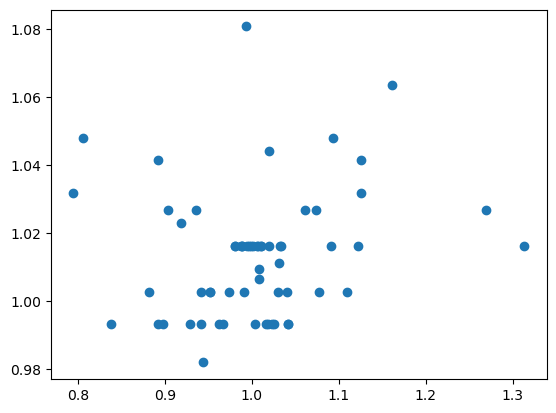

In [84]:
# Plot y_test vs y_pred

plt.scatter(y_test_resl, y_pred_resl)

### Resistance

In [85]:
# Define objevtice function
def objective_cv_rest(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rest, y_train_rest, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rest = fmin(
    fn = objective_cv_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 1000/1000 [03:35<00:00,  4.64trial/s, best loss: 0.06445547572179863]


In [86]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rest = xgb.XGBRegressor(
    eta = best_hyperparams_rest['eta'],
    gamma = best_hyperparams_rest['gamma'],
    max_depth = int(best_hyperparams_rest['max_depth']),
    min_child_weight = int(best_hyperparams_rest['min_child_weight']),
    subsample = best_hyperparams_rest['subsample'],
    colsample_bytree = best_hyperparams_rest['colsample_bytree'],
    alpha = best_hyperparams_rest['alpha']    
)


# Fit the model to the training data
xgb_rest.fit(X_train_rest, y_train_rest)

# Predict on the test set
y_pred_rest = xgb_rest.predict(X_test_rest)

In [87]:
# Predict on training data
y_pred_rest_train = xgb_rest.predict(X_train_rest)

# Predict on test data
y_pred_rest_test = xgb_rest.predict(X_test_rest)

# Compute R² on both
r2_train = r2_score(y_train_rest, y_pred_rest_train)
r2_test = r2_score(y_test_rest, y_pred_rest_test)

print(r2_test)
print(r2_train)

0.9442412894190049
0.9907081623334566


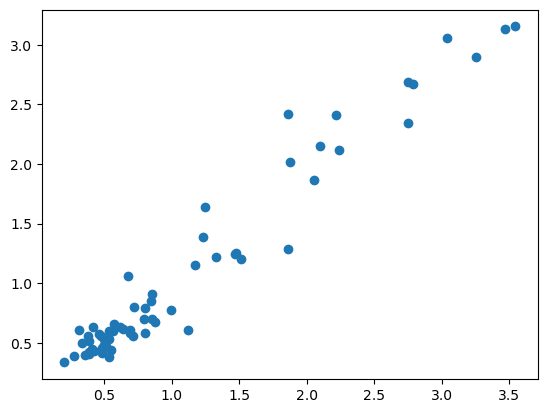

In [95]:
# Plot y_test vs y_pred

plt.scatter(y_test_rest, y_pred_rest_test)

### Recovery

In [89]:
# Define objevtice function
def objective_cv_rec(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha']
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rec, y_train_rec, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rec = fmin(
    fn = objective_cv_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 1000,
    trials = trials,
    rstate = np.random.default_rng(123)
)


  0%|          | 0/1000 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 1000/1000 [03:40<00:00,  4.53trial/s, best loss: 0.06445547572179863]


In [90]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rec = xgb.XGBRegressor(
    eta = best_hyperparams_rec['eta'],
    gamma = best_hyperparams_rec['gamma'],
    max_depth = int(best_hyperparams_rec['max_depth']),
    min_child_weight = int(best_hyperparams_rec['min_child_weight']),
    subsample = best_hyperparams_rec['subsample'],
    colsample_bytree = best_hyperparams_rec['colsample_bytree'],
    alpha = best_hyperparams_rec['alpha']    
)


# Fit the model to the training data
xgb_rec.fit(X_train_rec, y_train_rec)

# Predict on the test set
y_pred_rec = xgb_rec.predict(X_test_rec)

In [91]:
# Predict on training data
y_pred_rec_train = xgb_rec.predict(X_train_rec)

# Predict on test data
y_pred_rec_test = xgb_rec.predict(X_test_rec)

# Compute R² on both
r2_train = r2_score(y_train_rec, y_pred_rec_train)
r2_test = r2_score(y_test_rec, y_pred_rec_test)

print(r2_test)
print(r2_train)

0.9413118446136831
0.992330760253212


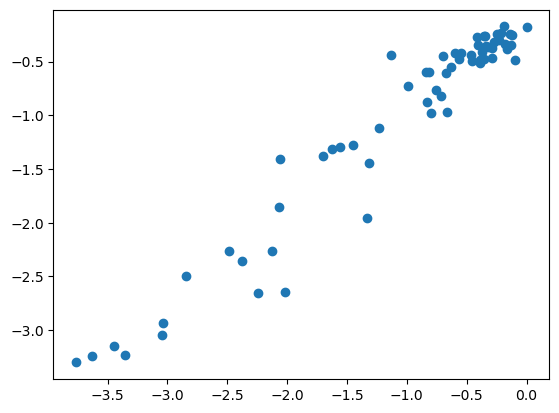

In [92]:
# Plot y_test vs y_pred

plt.scatter(y_test_rec, y_pred_rec)

### Feature importance